# Regresión Logística Binaria — APS Failure at Scania Trucks

**Universitario:** Huarachi Clemente Ariel  
**Dataset:** APS Failure at Scania Trucks  
**Fuente:** https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks  
**División:** 80% entrenamiento / 20% prueba

En este cuadernillo se implementa un modelo de **regresión logística binaria** aplicado al dataset **APS Failure at Scania Trucks**. El dataset contiene lecturas de **171 sensores** recopiladas de camiones Scania en operación real. El objetivo es predecir si una falla registrada en el camión corresponde al **Sistema de Presión de Aire (APS)**, componente encargado del frenado y los cambios de marcha.

La clasificación es binaria:
- Clase **pos = 1** → la falla es causada por el APS
- Clase **neg = 0** → la falla es causada por otro componente distinto al APS

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [1]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Para leer y preprocesar el archivo CSV con Pandas
import pandas as pd

# Librerias para graficar
from matplotlib import pyplot
import matplotlib
matplotlib.use('Agg')

# Modulo de optimización de scipy
from scipy import optimize

# Para la division 80% entrenamiento / 20% prueba
from sklearn.model_selection import train_test_split

# Para reducir las 171 features a 2D y poder graficar el limite de decision
from sklearn.decomposition import PCA

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [2]:
# Cargar datos
# Las 171 columnas contienen lecturas de sensores del camion (features)
# y la columna 'class' contiene la etiqueta: 'pos' = falla APS, 'neg' = no falla APS
# skiprows=20 omite los comentarios de cabecera del archivo UCI
# na_values='na' convierte los valores faltantes a NaN para poder procesarlos
df = pd.read_csv('aps_failure_training_set.csv', skiprows=20, na_values='na')

# Separar features y etiqueta
X_df = df.drop(columns=['class'])

# Imputar valores faltantes con la mediana de cada columna de sensor
X_df = X_df.fillna(X_df.median())

# Convertir etiquetas de texto a numerico: 'pos' -> 1, 'neg' -> 0
y_series = df['class'].map({'pos': 1, 'neg': 0})

# Convertir a arrays numpy
X = X_df.values.astype(float)
y = y_series.values.astype(float)

print(X)
print(y)

[[7.66980000e+04 0.00000000e+00 2.13070644e+09 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [3.30580000e+04 0.00000000e+00 0.00000000e+00 ... 1.50000000e+03
  0.00000000e+00 0.00000000e+00]
 [4.10400000e+04 0.00000000e+00 2.28000000e+02 ... 5.14000000e+02
  0.00000000e+00 0.00000000e+00]
 ...
 [1.12000000e+02 0.00000000e+00 2.13070643e+09 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [8.02920000e+04 0.00000000e+00 2.13070643e+09 ... 3.88422000e+05
  0.00000000e+00 0.00000000e+00]
 [4.02220000e+04 0.00000000e+00 6.98000000e+02 ... 1.58000000e+02
  0.00000000e+00 0.00000000e+00]]
[0. 0. 0. ... 0. 0. 0.]


### 1.1 Visualizar los datos

Antes de implementar el modelo es importante visualizar los datos. El dataset APS tiene **171 features de sensores** por lo que no es posible graficar directamente en 2D. Se aplica **PCA** para reducir las 171 dimensiones a 2 componentes y poder graficar los ejemplos usando los mismos marcadores: `*` para camiones con falla APS (pos=1) y `o` para camiones sin falla APS (neg=0).

In [3]:
def plotData(X, y):
    # Grafica los puntos de datos X y y en una nueva figura.
    # Grafica los puntos de datos con * para los positivos (falla APS)
    # y o para los negativos (no falla APS)

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

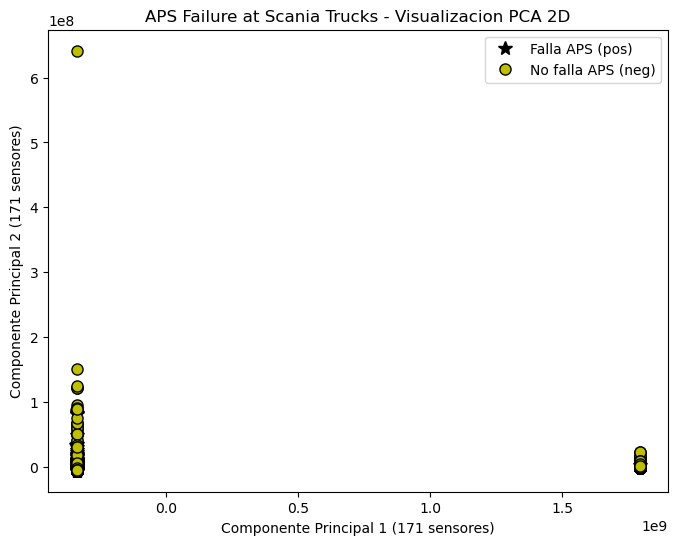

In [4]:
# Reducir las 171 features a 2 componentes con PCA para poder visualizar
pca_viz  = PCA(n_components=2, random_state=42)
X_2d_viz = pca_viz.fit_transform(X)

# Muestra de 3000 puntos para que la grafica sea legible
np.random.seed(42)
idx_viz = np.random.choice(X_2d_viz.shape[0], size=3000, replace=False)

# Se llama a la funcion implementada para mostrar los datos cargados
pyplot.figure(figsize=(8, 6))
plotData(X_2d_viz[idx_viz], y[idx_viz])
# adiciona etiquetas para los ejes
pyplot.xlabel('Componente Principal 1 (171 sensores)')
pyplot.ylabel('Componente Principal 2 (171 sensores)')
pyplot.legend(['Falla APS (pos)', 'No falla APS (neg)'])
pyplot.title('APS Failure at Scania Trucks - Visualizacion PCA 2D')
pyplot.show()

### 1.2 Implementación

#### 1.2.0 Normalización de Features

Los 171 sensores del camión miden magnitudes físicas completamente distintas con rangos muy diferentes entre sí: presión de aire, temperatura, contadores de ciclos, entre otros. Sin normalización el descenso por el gradiente converge muy lento porque los sensores con valores grandes dominan el cálculo sobre los sensores con valores pequeños.

La normalización estandariza cada feature para que tenga **media = 0** y **desviación estándar = 1**:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar de cada columna calculadas sobre todos los 60,000 camiones. Columnas con $\sigma = 0$ reciben $\sigma = 10^{-8}$ para evitar división por cero.

La normalización se aplica **antes** de la división 80/20. La columna de unos (término de intercepción) se agrega **después** de normalizar para que el valor `1` no sea alterado.

In [5]:
# Función de Normalización
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Para evitar dividir por cero en columnas que tengan valores constantes
    sigma[sigma == 0] = 1e-8

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Aplicar normalizacion a la matriz X completa
X_norm, mu, sigma = featureNormalize(X)

print('Normalizacion terminada!')
print('Nuevo tamaño de la matriz X normalizada:', X_norm.shape)

Normalizacion terminada!
Nuevo tamaño de la matriz X normalizada: (60000, 170)


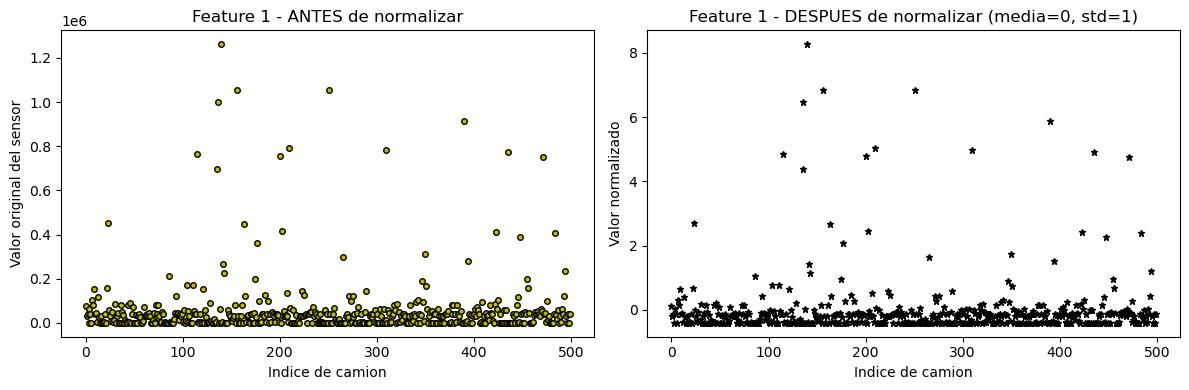

In [6]:
# Grafica comparativa: antes y despues de normalizar (primera feature del sensor)
pyplot.figure(figsize=(12, 4))

pyplot.subplot(1, 2, 1)
pyplot.plot(range(500), X[:500, 0], 'ko', mfc='y', ms=4, mec='k', mew=1)
pyplot.xlabel('Indice de camion')
pyplot.ylabel('Valor original del sensor')
pyplot.title('Feature 1 - ANTES de normalizar')

pyplot.subplot(1, 2, 2)
pyplot.plot(range(500), X_norm[:500, 0], 'k*', lw=2, ms=5)
pyplot.xlabel('Indice de camion')
pyplot.ylabel('Valor normalizado')
pyplot.title('Feature 1 - DESPUES de normalizar (media=0, std=1)')

pyplot.tight_layout()
pyplot.show()

#### División 80% Entrenamiento / 20% Prueba

La división se aplica sobre `X_norm`. Se usa `stratify=y` para mantener la proporción de clases pos/neg en ambos conjuntos. Los datos de prueba **no se usan en ningún momento del entrenamiento**, garantizando una evaluación honesta del modelo.

Division completada:
  Entrenamiento (80%): 48000 instancias - 170 features
  Prueba        (20%): 12000 instancias
Nuevo tamaño de la matriz X_train (con la columna de unos extra): (48000, 171)
Nuevo tamaño de la matriz X_test  (con la columna de unos extra): (12000, 171)


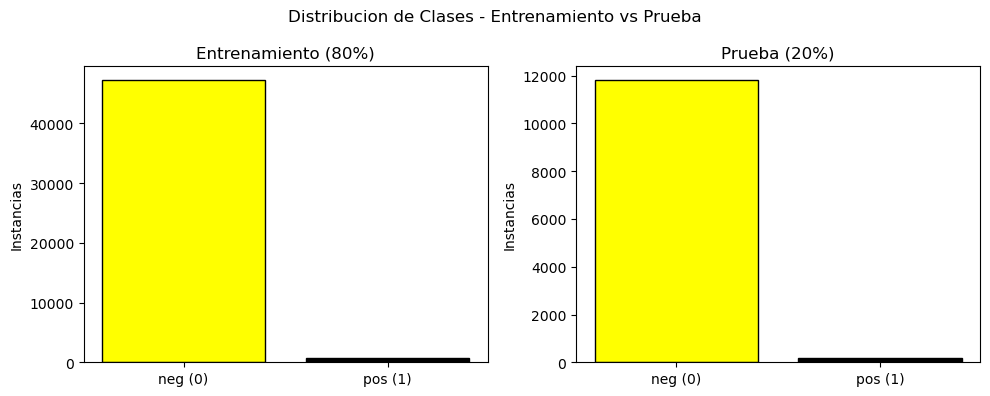

In [7]:
# Division 80% entrenamiento / 20% prueba sobre X normalizado
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y,
    test_size    = 0.20,
    train_size   = 0.80,
    random_state = 42,
    stratify     = y
)

m_train, n = X_train.shape
m_test     = X_test.shape[0]

print('Division completada:')
print('  Entrenamiento (80%):', m_train, 'instancias -', n, 'features')
print('  Prueba        (20%):', m_test,  'instancias')

# Configurar la matriz adecuadamente, y agregar una columna de unos
# que corresponde al termino de intercepcion — se hace DESPUES de normalizar
X_train = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
X_test  = np.concatenate([np.ones((m_test,  1)), X_test],  axis=1)

print('Nuevo tamaño de la matriz X_train (con la columna de unos extra):', X_train.shape)
print('Nuevo tamaño de la matriz X_test  (con la columna de unos extra):', X_test.shape)

# Grafica de la distribucion en cada conjunto
pyplot.figure(figsize=(10, 4))

pyplot.subplot(1, 2, 1)
pyplot.bar([0, 1],
           [int((y_train==0).sum()), int((y_train==1).sum())],
           color=['yellow', 'black'], edgecolor='black')
pyplot.xticks([0, 1], ['neg (0)', 'pos (1)'])
pyplot.title('Entrenamiento (80%)')
pyplot.ylabel('Instancias')

pyplot.subplot(1, 2, 2)
pyplot.bar([0, 1],
           [int((y_test==0).sum()), int((y_test==1).sum())],
           color=['yellow', 'black'], edgecolor='black')
pyplot.xticks([0, 1], ['neg (0)', 'pos (1)'])
pyplot.title('Prueba (20%)')
pyplot.ylabel('Instancias')

pyplot.suptitle('Distribucion de Clases - Entrenamiento vs Prueba')
pyplot.tight_layout()
pyplot.show()

#### 1.2.1 Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$

Para el dataset APS, $z$ es la combinación lineal de los **171 sensores normalizados** del camión ponderados por los parámetros $\theta$. El resultado $g(z)$ representa la **probabilidad de que el camión tenga una falla en el sistema APS**. Valores cercanos a 1 indican alta probabilidad de falla APS, valores cercanos a 0 indican baja probabilidad.

In [8]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


#### 1.2.2 Función de Costo y Gradiente

La función de costo $J(\theta)$ cuantifica qué tan equivocado está el modelo al clasificar los camiones. Penaliza cuando predice alta probabilidad de falla APS en un camión sin falla APS, y viceversa:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

El gradiente indica en qué dirección se deben ajustar los 172 parámetros $\theta$ para reducir el costo:

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)}$$

In [9]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    J    = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

# Se prueba la funcion costFunction con dos casos de prueba para theta

# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n + 1)
print(initial_theta)
cost, grad = costFunction(initial_theta, X_train, y_train)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')
print(grad[:3])
print('Gradiente en theta inicial (zeros):')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad[:3]))

# Calcula y muestra el costo con valores de theta diferentes a cero
test_theta = np.concatenate([[-24, 0.2, 0.2], np.zeros(n - 2)])
print(test_theta[:3])
cost, grad = costFunction(test_theta, X_train, y_train)

print('Costo en theta prueba: {:.3f}'.format(cost))
print('Gradiente en theta prueba (primeros 3):')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*grad[:3]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Costo esperado (aproximado): 0.693

[ 0.48333333 -0.06860892 -0.00174094]
Gradiente en theta inicial (zeros):
	[0.4833, -0.0686, -0.0017]
[-24.    0.2   0.2]
Costo en theta prueba: 0.386
Gradiente en theta prueba (primeros 3):
	[-0.017, -0.068, -0.000]


#### Descenso por el Gradiente

El descenso por el gradiente ajusta los 172 parámetros $\theta$ iterativamente minimizando el costo $J$. Gracias a la normalización previa todos los 171 sensores están en la misma escala, lo que permite que el gradiente avance de forma uniforme y la convergencia sea estable. El gráfico de costo muestra cómo $J$ decrece con cada iteración hasta estabilizarse.

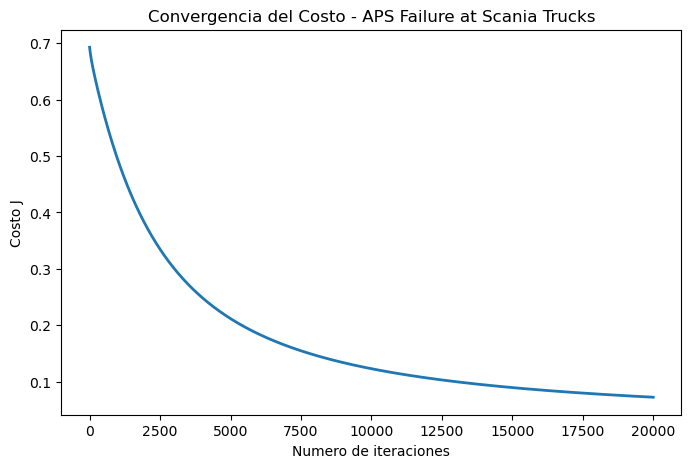

theta calculado por el descenso por el gradiente (primeros 5): [-2.78380121e+00  6.29191702e-02 -7.45845593e-03 -9.26848210e-03
 -3.27739950e-04]
Probabilidad de falla APS para el camion de ejemplo (descenso gradiente): 0


In [10]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

# Elegir algun valor para alpha (probar varias alternativas)
alpha     = 0.001
num_iters = 20000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n + 1)
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo - APS Failure at Scania Trucks')
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente (primeros 5): {:s}'.format(str(theta[:5])))

# Verificar probabilidad de falla APS para un camion del dataset
X_ejemplo  = (X[0] - mu) / sigma
X_array    = np.concatenate([[1], X_ejemplo])
prob_falla = sigmoid(np.dot(X_array, theta))
print('Probabilidad de falla APS para el camion de ejemplo (descenso gradiente): {:.0f}'.format(prob_falla))

#### 1.2.3 Parámetros de aprendizaje usando `scipy.optimize`

En lugar de realizar los pasos del descenso por el gradiente manualmente, se utiliza el módulo `scipy.optimize`. Proporciona el método `minimize` que busca los valores de $\theta$ que minimizan la función de costo de manera más eficiente. Se utiliza el método **TNC (Newton Truncado)** que aprovecha la información del gradiente para converger sin necesidad de definir manualmente la tasa de aprendizaje $\alpha$ ni el número de iteraciones.

A continuación se tiene el código para llamar a `optimize.minimize` con los argumentos correctos.

In [11]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n + 1)
print(initial_theta)
cost, grad = costFunction(initial_theta, X_train, y_train)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')
print(grad[:3])
print('Gradiente en theta inicial (zeros):')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad[:3]))

# Calcula y muestra el costo con valores de theta diferentes a cero
test_theta = np.concatenate([[-24, 0.2, 0.2], np.zeros(n - 2)])
print(test_theta[:3])
cost, grad = costFunction(test_theta, X_train, y_train)

print('Costo en theta prueba: {:.3f}'.format(cost))
print('Gradiente en theta prueba (primeros 3):')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*grad[:3]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Costo esperado (aproximado): 0.693

[ 0.48333333 -0.06860892 -0.00174094]
Gradiente en theta inicial (zeros):
	[0.4833, -0.0686, -0.0017]
[-24.    0.2   0.2]
Costo en theta prueba: 0.386
Gradiente en theta prueba (primeros 3):
	[-0.017, -0.068, -0.000]


In [12]:
# Establecer las opciones para optimize.minimize
options = {'maxiter': 1000}

# La funcion devuelve un objeto OptimizeResult
# Se utiliza el algoritmo de Newton truncado para la optimización.
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

# la propiedad fun del objeto devuelto por OptimizeResult
# contiene el valor del costFunction de un theta optimizado
cost = res.fun

# Theta optimizada esta en la propiedad x
theta = res.x

print('Costo con un valor de theta encontrado por optimize.minimize: {:.3f}'.format(cost))
print('Iteraciones: {}  |  Exitoso: {}'.format(res.nit, res.success))

C:\Users\ariel\AppData\Local\Temp\ipykernel_26636\3378894959.py:6: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,
C:\Users\ariel\AppData\Local\Temp\ipykernel_26636\3189698869.py:20: RuntimeWarning: divide by zero encountered in log
  J    = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))


Costo con un valor de theta encontrado por optimize.minimize: 0.149
Iteraciones: 1  |  Exitoso: False


Una vez que se completa `optimize.minimize`, se usa el valor final de $\theta$ para visualizar el límite de decisión en los datos de entrenamiento. Se implementa la función `plotDecisionBoundary` que traza el límite de decisión sobre los datos. Como el dataset APS tiene 171 features, se usa PCA para proyectar el espacio a 2D y poder trazar la línea de separación entre camiones con falla APS y sin falla APS.

In [13]:
def plotDecisionBoundary(plotData, theta, X, y):
    """
    Grafica los puntos X y Y en una nueva figura con un limite de desicion definido por theta.
    Grafica los puntos con * para los ejemplos positivos (falla APS)
    y con o para los ejemplos negativos (no falla APS).

    Parametros:
    ----------
    plotData : func
        Funcion de referencia para graficar los datos X, y.

    theta : array_like
        Parametros para la regresion logistica. Un vector de la forma (n+1, ).

    X : array_like
        Dataset de entrada. La primera columna es la columna de unos (intercepcion).

    y : array_like
        Vector de datos de etiquetas de la forma (m, ).
    """
    # hacer que theta sera un arreglo numpy
    theta = np.array(theta)

    # Graficar los datos (recordar que la primera columna en X es la intercepcion)
    plotData(X[:, 1:3], y)

    if X.shape[1] <= 3:
        # Solo se requieren 2 puntos para definir una linea
        plot_x = np.array([np.min(X[:, 1]) - 2, np.max(X[:, 1]) + 2])

        # Calcular la linea limite de decision
        plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

        print(plot_x)
        print(plot_y)
        # Graficar y ajustar los ejes para una mejor visualizacion
        pyplot.plot(plot_x, plot_y)

        # Leyenda
        pyplot.legend(['Falla APS (pos)', 'No falla APS (neg)', 'Limite de decision'])
        pyplot.xlim([np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1])
        pyplot.ylim([np.min(X[:, 2]) - 1, np.max(X[:, 2]) + 1])
    else:
        # Rango de la grilla
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)

        z = np.zeros((u.size, v.size))
        # Evalua z = theta*x sobre la grilla
        for i, ui in enumerate(u):
            for j, vj in enumerate(v):
                punto = np.concatenate([[1, ui, vj], np.zeros(theta.shape[0] - 3)])
                z[i, j] = np.dot(punto, theta)

        z = z.T  # importante transponer z antes de llamar al contorno

        # Plot z = 0
        pyplot.contour(u, v, z, levels=[0], linewidths=2, colors='g')
        pyplot.contourf(u, v, z, levels=[np.min(z), 0, np.max(z)], cmap='Greens', alpha=0.4)

Varianza explicada por PCA (2 componentes): 32.56%
[ -5.22741652 110.90636948]
[nan nan]


C:\Users\ariel\AppData\Local\Temp\ipykernel_26636\3535812538.py:14: OptimizeWarning: Unknown solver options: maxiter
  res_2d   = optimize.minimize(costFunction, np.zeros(3),
C:\Users\ariel\AppData\Local\Temp\ipykernel_26636\3189698869.py:20: RuntimeWarning: divide by zero encountered in log
  J    = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
C:\Users\ariel\AppData\Local\Temp\ipykernel_26636\972356147.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])
C:\Users\ariel\AppData\Local\Temp\ipykernel_26636\972356147.py:32: RuntimeWarning: invalid value encountered in multiply
  plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])


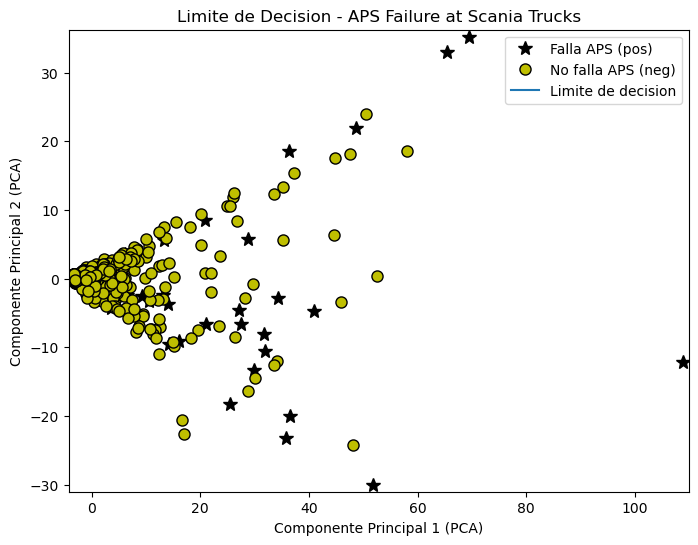

In [14]:
# Reducir las 171 features normalizadas a 2 componentes con PCA
# X_train[:,1:] excluye la columna de intercepcion antes de aplicar PCA
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train[:, 1:])

print('Varianza explicada por PCA (2 componentes): {:.2f}%'.format(
    pca.explained_variance_ratio_.sum() * 100))

# Agregar columna de intercepcion al espacio 2D
m2    = X_2d.shape[0]
X_2db = np.concatenate([np.ones((m2, 1)), X_2d], axis=1)

# Optimizar theta en el espacio 2D solo para visualizar el limite de decision
res_2d   = optimize.minimize(costFunction, np.zeros(3),
                              (X_2db, y_train),
                              jac=True, method='TNC',
                              options={'maxiter': 1000})
theta_2d = res_2d.x

# Muestra de 2000 puntos para que el grafico sea legible
np.random.seed(42)
idx = np.random.choice(m2, size=2000, replace=False)

# Graficar limites
pyplot.figure(figsize=(8, 6))
plotDecisionBoundary(plotData, theta_2d, X_2db[idx], y_train[idx])
pyplot.xlabel('Componente Principal 1 (PCA)')
pyplot.ylabel('Componente Principal 2 (PCA)')
pyplot.title('Limite de Decision - APS Failure at Scania Trucks')
pyplot.show()

#### 1.2.4 Evaluación de la Regresión Logística

Después de aprender los parámetros, se usa el modelo para predecir si un camión tiene falla APS. Para verificar la efectividad del modelo se predice la probabilidad de falla APS para un camión de ejemplo del dataset, normalizando sus valores de sensor con los mismos $\mu$ y $\sigma$ calculados durante el entrenamiento. Se evalúa la precisión tanto en el conjunto de entrenamiento (80%) como en el conjunto de prueba (20%).

In [15]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresion logistica aprendida.
    Calcula las predicciones para X usando un umbral en 0.5
    (es decir, si sigmoide (theta.T * x) >= 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vector de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones 0 o 1 para cada fila en X.
    """
    m = X.shape[0] # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# Predice la probabilidad de falla APS para un camion de ejemplo del dataset
X_ejemplo = (X[0] - mu) / sigma
X_array   = np.concatenate([[1], X_ejemplo])
prob = sigmoid(np.dot(X_array, theta))
print('Probabilidad de falla APS para el camion de ejemplo: {:.3f}'.format(prob))
print('Prediccion (1=falla APS, 0=no falla APS): {:.0f}'.format(prob))

# Precision de entrenamiento
p_train = predict(theta, X_train)
print('Precision de entrenamiento (80%): {:.2f} %'.format(np.mean(p_train == y_train) * 100))

# Precision de prueba
p_test  = predict(theta, X_test)
print('Precision de prueba        (20%): {:.2f} %'.format(np.mean(p_test == y_test) * 100))

Probabilidad de falla APS para el camion de ejemplo: 0.143
Prediccion (1=falla APS, 0=no falla APS): 0
Precision de entrenamiento (80%): 98.90 %
Precision de prueba        (20%): 98.77 %


Una vez entrenado el modelo se procede a analizar los resultados en detalle. Se calcula la **matriz de confusión** para ver exactamente cuántos camiones fueron clasificados correctamente e incorrectamente. Se evalúa también el **costo total** según la métrica oficial del challenge APS Scania:
- **$10** por cada falso positivo → revisión innecesaria en taller
- **$500** por cada falso negativo → camión con falla APS llega a la ruta

Matriz de Confusion (Prueba 20%):
        Predicho neg  Predicho pos
Real neg:  TN=11,764     FP=    36
Real pos:  FN=   112     TP=    88

Precision (Precision): 0.7097
Recall    (Recall)   : 0.4400
F1-Score             : 0.5432

Costo total del challenge APS Scania:
  FP x $10  (36 x 10) = $360
  FN x $500 (112 x 500) = $56000
  Costo Total: $56360


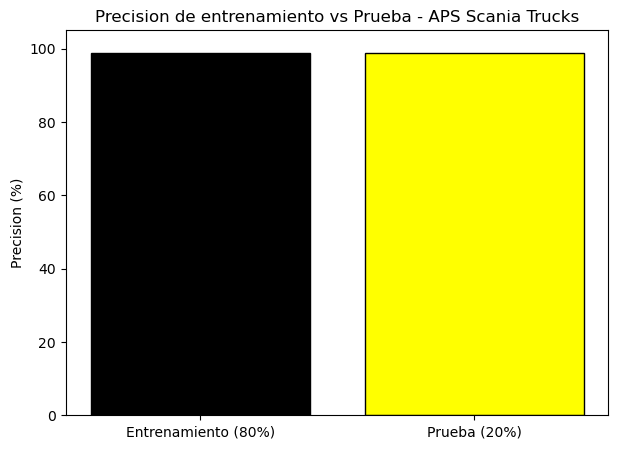

In [16]:
# Matriz de confusion sobre el conjunto de prueba (20%)
TP = int(np.sum((p_test == 1) & (y_test == 1)))
TN = int(np.sum((p_test == 0) & (y_test == 0)))
FP = int(np.sum((p_test == 1) & (y_test == 0)))
FN = int(np.sum((p_test == 0) & (y_test == 1)))

print('Matriz de Confusion (Prueba 20%):')
print('        Predicho neg  Predicho pos')
print('Real neg:  TN={:6,}     FP={:6,}'.format(TN, FP))
print('Real pos:  FN={:6,}     TP={:6,}'.format(FN, TP))

# Metricas de la clase positiva
precision_m = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_m    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_m        = 2*precision_m*recall_m/(precision_m+recall_m) if (precision_m+recall_m) > 0 else 0
print()
print('Precision (Precision): {:.4f}'.format(precision_m))
print('Recall    (Recall)   : {:.4f}'.format(recall_m))
print('F1-Score             : {:.4f}'.format(f1_m))

# Costo total segun la metrica oficial del challenge APS Scania
print()
print('Costo total del challenge APS Scania:')
print('  FP x $10  ({} x 10) = ${}'.format(FP, FP * 10))
print('  FN x $500 ({} x 500) = ${}'.format(FN, FN * 500))
print('  Costo Total: ${}'.format(FP * 10 + FN * 500))

# Grafica comparativa precision entrenamiento vs prueba
pyplot.figure(figsize=(7, 5))
pyplot.bar([0, 1],
           [np.mean(p_train == y_train) * 100, np.mean(p_test == y_test) * 100],
           color=['black', 'yellow'], edgecolor='black')
pyplot.xticks([0, 1], ['Entrenamiento (80%)', 'Prueba (20%)'])
pyplot.ylim([0, 105])
pyplot.ylabel('Precision (%)')
pyplot.title('Precision de entrenamiento vs Prueba - APS Scania Trucks')
pyplot.show()